
# **Richter's Predictor: Earthquake Damage Modeling**


## **1. Problem Statement**

**📌 Business Objective**

The primary business objective of this project is to accurately predict the level of structural damage to buildings after an earthquake using pre-earthquake building characteristics such as location, construction material, foundation type, age, and socio-economic-demographic statistics.

By automating damage assessment through machine learning, the model aims to support faster, data-driven decision-making in post-disaster scenarios where manual inspections are time-consuming, costly, and often infeasible at scale.

**🎯 Business Goal**

The goal of this project is to build a robust and scalable predictive model that classifies buildings into three ordinal damage categories:

* Low Damage (Grade 1)

* Medium Damage (Grade 2)

* Severe Damage / Near Destruction (Grade 3)

**Machine Learning Type:–** Multiclass Classification

## **2. Importing Libraries**

In [ ]:
import numpy as np    # for fast mathematical operation
import pandas as pd   # for data analysis & manipulation of huge data and make decisions based on statistical theories
import matplotlib.pyplot as plt  # for visualize interactive plots
import seaborn as sns     # for visualize the plots
import warnings
warnings.filterwarnings("ignore" )   # ignores non-priority warnings

## **3. Load Data Set**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = pd.read_csv("/content/drive/MyDrive/project/Earthquake/train_values.csv")  # it has only input features
df2 = pd.read_csv("/content/drive/MyDrive/project/Earthquake/train_labels.csv")  # it has only output features

## **4. Basic Checks**

In [ ]:
df1.head()  # shows top 5 rows of features data

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df1.tail()  # shows last 5 rows of features data

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,0
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,0
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,0
260600,747594,21,9,9101,3,10,7,6,n,r,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df1.sample(10) # shows random 10 sample of features data

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
77548,633847,10,1074,8784,2,5,8,5,t,r,...,0,0,0,0,0,0,0,0,0,0
239641,656013,4,450,6718,3,15,6,7,t,r,...,0,0,0,0,0,0,0,0,0,0
150091,935393,8,178,8600,3,50,9,9,n,r,...,0,0,0,0,0,0,0,0,0,0
176457,333042,17,21,3978,3,10,6,6,t,r,...,0,0,0,0,0,0,0,0,0,0
197186,502288,11,131,9613,3,40,5,7,n,r,...,0,0,0,0,0,0,0,0,0,0
108882,830238,10,1397,1499,2,10,5,4,n,r,...,0,0,0,0,0,0,0,0,0,0
93862,333543,6,104,11611,2,35,4,5,n,r,...,0,0,0,0,0,0,0,0,0,0
187256,602787,0,793,5027,2,30,6,6,t,r,...,0,0,0,0,0,0,0,0,0,0
246007,342536,7,157,1548,2,15,18,5,t,r,...,0,0,0,0,0,0,0,0,0,0
175615,292169,6,931,4371,2,5,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df1.shape # shows rows,columns of features data

(260601, 39)

In [ ]:
df2.head()  # shows top 5 rows of label data

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3


In [ ]:
df2.tail()  # shows last 5 rows of label data

,building_id,damage_grade
260596,688636,2
260597,669485,3
260598,602512,3
260599,151409,2
260600,747594,3


In [ ]:
df2.sample(10) # shows random 10 sample of label data

,building_id,damage_grade
50491,264368,3
19431,968228,2
24882,584565,2
220872,602982,3
138576,76189,3
176918,475996,1
13827,142662,3
195081,103052,2
219156,847562,2
171915,252433,2


In [ ]:
df2.shape # shows rows,columns of label data

(260601, 2)

* As we observe, both datasets have the same **no. of records(260601)**. There are **39 columns** in this features dataset, where the 'building_id' column is a unique and random identifier for both datasets. So, adding both datasets for further use.

In [ ]:
# merging both the datasets
df = pd.merge(df1,df2,on= 'building_id',how ='left',)
df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2


In [ ]:
df.shape

(260601, 40)

In [ ]:
df.size

10424040

In [ ]:
df.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

* Dataset does't have any missing values

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
building_id,260601.0,525675.482773,304544.999032,4.0,261190.0,525757.0,789762.0,1052934.0
geo_level_1_id,260601.0,13.900353,8.033617,0.0,7.0,12.0,21.0,30.0
geo_level_2_id,260601.0,701.074685,412.710734,0.0,350.0,702.0,1050.0,1427.0
geo_level_3_id,260601.0,6257.876148,3646.369645,0.0,3073.0,6270.0,9412.0,12567.0
count_floors_pre_eq,260601.0,2.129723,0.727665,1.0,2.0,2.0,2.0,9.0
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
area_percentage,260601.0,8.018051,4.392231,1.0,5.0,7.0,9.0,100.0
height_percentage,260601.0,5.434365,1.918418,2.0,4.0,5.0,6.0,32.0
has_superstructure_adobe_mud,260601.0,0.088645,0.284231,0.0,0.0,0.0,0.0,1.0
has_superstructure_mud_mortar_stone,260601.0,0.761935,0.425900,0.0,1.0,1.0,1.0,1.0


## **5. Domain Analysis**📔
•	**geo_level_1_id, geo_level_2_id, geo_level_3_id (type: int):**
 geographic region in which building exists, from largest (level 1) to most specific sub-region (level 3). Possible values: level 1: 0-30, level 2: 0-1427, level 3: 0-12567.

•	**count_floors_pre_eq (type: int):**
 number of floors in the building before the earthquake.

•	**age (type: int):**  age of the building in years.

•	**area_percentage (type: int):**  normalized area of the building footprint.

•	**height_percentage (type: int):** normalized height of the building footprint.

•	**land_surface_condition (type: categorical):**  surface condition of the land where the building was built. Possible values: n, o, t.

•	**foundation_type (type: categorical):**  type of foundation used while building. Possible values: h, i, r, u, w.

•	**roof_type (type: categorical):**  type of roof used while building. Possible values: n, q, x.

•	**ground_floor_type (type: categorical):**  type of the ground floor. Possible values: f, m, v, x, z.

•	**other_floor_type (type: categorical):** type of constructions used in higher than the ground floors (except of roof). Possible values: j, q, s, x.

•	**position (type: categorical):** position of the building. Possible values: j, o, s, t.

•	**plan_configuration (type: categorical):** building plan configuration. Possible values: a, c, d, f, m, n, o, q, s, u.

•	**has_superstructure_adobe_mud (type: binary):** flag variable that indicates if the superstructure was made of Adobe/Mud.

•	**has_superstructure_mud_mortar_stone (type: binary):** flag variable that indicates if the superstructure was made of Mud Mortar - Stone.

•	**has_superstructure_stone_flag (type: binary):**  flag variable that indicates if the superstructure was made of Stone.

•	**has_superstructure_cement_mortar_stone (type: binary):**  flag variable that indicates if the superstructure was made of Cement Mortar - Stone.

•	**has_superstructure_mud_mortar_brick (type: binary):**  flag variable that indicates if the superstructure was made of Mud Mortar - Brick.

•	**has_superstructure_cement_mortar_brick (type: binary):** flag variable that indicates if the superstructure was made of Cement Mortar - Brick.

•	**has_superstructure_timber (type: binary):**  flag variable that indicates if the superstructure was made of Timber.

•	**has_superstructure_bamboo (type: binary):**  flag variable that indicates if the superstructure was made of Bamboo.

•	**has_superstructure_rc_non_engineered (type: binary):**  flag variable that indicates if the superstructure was made of non-engineered reinforced concrete.

•	**has_superstructure_rc_engineered (type: binary):**  flag variable that indicates if the superstructure was made of engineered reinforced concrete.

•	**has_superstructure_other (type: binary):** flag variable that indicates if the superstructure was made of any other material.

•	**legal_ownership_status (type: categorical):** legal ownership status of the land where building was built. Possible values: a, r, v, w.

•	**count_families (type: int):** number of families that live in the building.

•	**has_secondary_use (type: binary):** flag variable that indicates if the building was used for any secondary purpose.

•	**has_secondary_use_agriculture (type: binary):** flag variable that indicates if the building was used for agricultural purposes.

•	**has_secondary_use_hotel (type: binary):** flag variable that indicates if the building was used as a hotel.

•	**has_secondary_use_rental (type: binary):** flag variable that indicates if the building was used for rental purposes.

•	**has_secondary_use_institution (type: binary):**  flag variable that indicates if the building was used as a location of any institution.

•	**has_secondary_use_school (type: binary):**  flag variable that indicates if the building was used as a school.

•	**has_secondary_use_industry (type: binary):**  flag variable that indicates if the building was used for industrial purposes.

•	**has_secondary_use_health_post (type: binary):** flag variable that indicates if the building was used as a health post.

•	**has_secondary_use_gov_office (type: binary):** flag variable that indicates if the building was used as a government office.

•	**has_secondary_use_use_police (type: binary):** flag variable that indicates if the building was used as a police station.

•	**has_secondary_use_other (type: binary):**  flag variable that indicates if the building was secondarily used for other purposes.




## **6. Exploratory Data Analysis (EDA)📊**


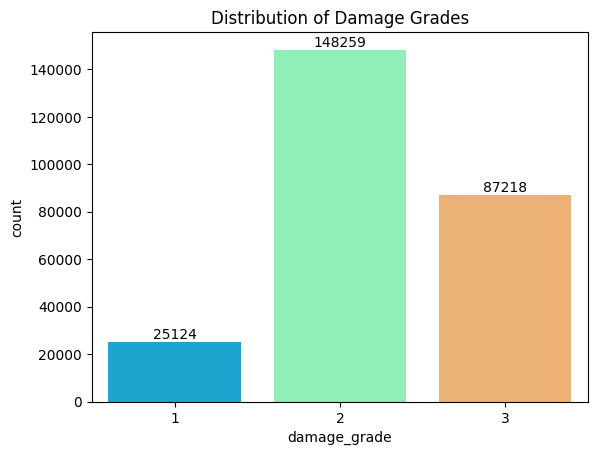

In [ ]:
ax = sns.countplot(x='damage_grade', data=df,palette='rainbow')

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(
        f'{count}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title('Distribution of Damage Grades')
plt.show()


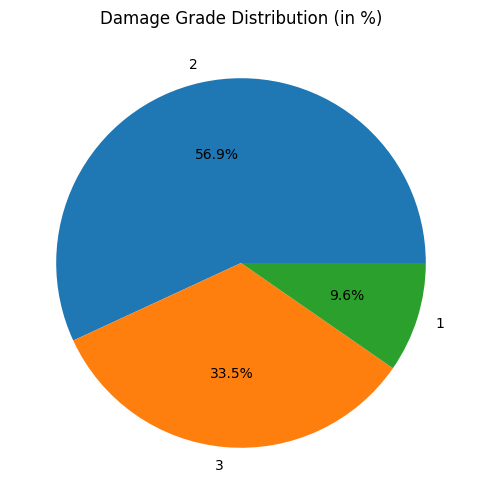

In [ ]:
counts = df['damage_grade'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Damage Grade Distribution (in %)")
plt.show()

####**Insights**
* Data is imbalanced
* Grade 2 (Severe Damage) buildings dominate
* We'll use the macro F1 metric

In [ ]:
df['count_floors_pre_eq'].value_counts()

,count
count_floors_pre_eq,
2,156623
3,55617
1,40441
4,5424
5,2246
6,209
7,39
8,1
9,1


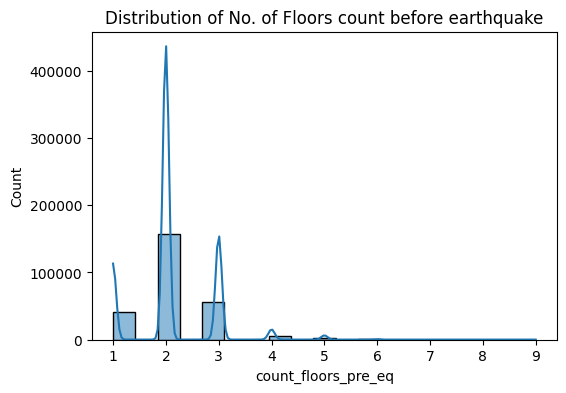

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df,x='count_floors_pre_eq',kde='True')
plt.title('Distribution of No. of Floors count before earthquake')
plt.show()

####**Insights**
* Data is not normally distributed.
* Distribution is highly skewed.
* The number of floors is up to 9, and long tail shows most of the buildings have floors upto 3.

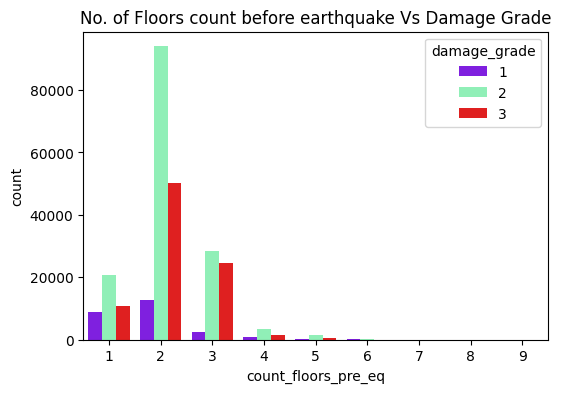

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='count_floors_pre_eq',hue='damage_grade',palette='rainbow')
plt.title('No. of Floors count before earthquake Vs Damage Grade')
plt.show()

####**Insights**
* Most of the buildings that were affected have upto 3 floors.

In [ ]:
df['age'].value_counts().sort_index(ascending=False)

,count
age,
995,1390
200,106
195,2
190,3
185,1
180,7
175,5
170,6
165,2


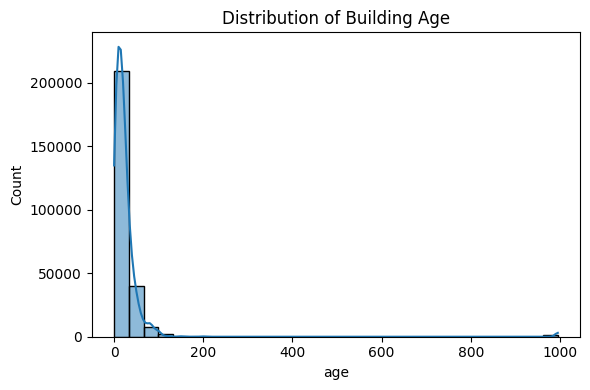

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Distribution of Building Age")
plt.tight_layout()
plt.show()

####**Insights**
* The distribution of the age column is right-skewed, which means many old buildings have.
* The long tail shows that few ancient buildings have.

In [ ]:
df['area_percentage'].value_counts().sort_index(ascending=True)

,count
area_percentage,
1,90
2,3181
3,11837
4,19236
5,32724
...,...
85,4
86,5
90,1


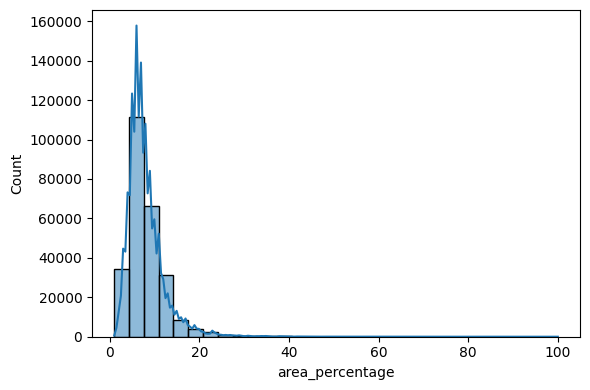

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['area_percentage'], bins=30, kde=True)
plt.tight_layout()
plt.show()

####**Insights**
* Data is right-skewed
* Few buildings have a larger area
* Normalised area percentage of buildings is less than 20%.

In [ ]:
df['height_percentage'].value_counts()

,count
height_percentage,
5,78513
6,46477
4,37763
7,35465
3,25957
8,13902
2,9305
9,5376
10,4492


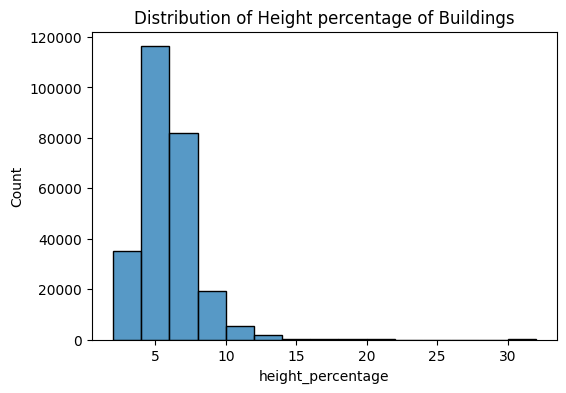

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['height_percentage'],binwidth=2)
plt.title('Distribution of Height percentage of Buildings')
plt.show()

####**Insights**
* Data has a long tail.
* Only few buildings have the longest height.
* Normalised height percentage of buildings is less than 10%.

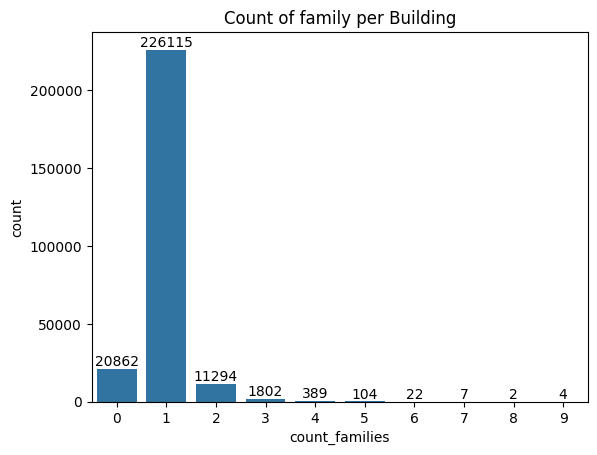

In [ ]:
total=len(df)
ax=sns.countplot(data=df,x='count_families')
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(
        f'{count}',
        (p.get_x() + p.get_width() / 2.,p.get_height()),
        ha='center', va='bottom'
    )
plt.title("Count of family per Building")
plt.show()

####**Insights**
* A few buildings have big families.
* Most of the buildings have a family upto 2.

## **7. Data Preprocessing**

In [ ]:
# to check missing value
df.isnull().sum()

,0
building_id,0
geo_level_1_id,0
geo_level_2_id,0
geo_level_3_id,0
count_floors_pre_eq,0
age,0
area_percentage,0
height_percentage,0
land_surface_condition,0
foundation_type,0


In [ ]:
# to check duplicates
df.duplicated().sum()

np.int64(0)

#### **Insights**
* There is no null value
* There is zero duplicate record.

### **Handling Outliers**

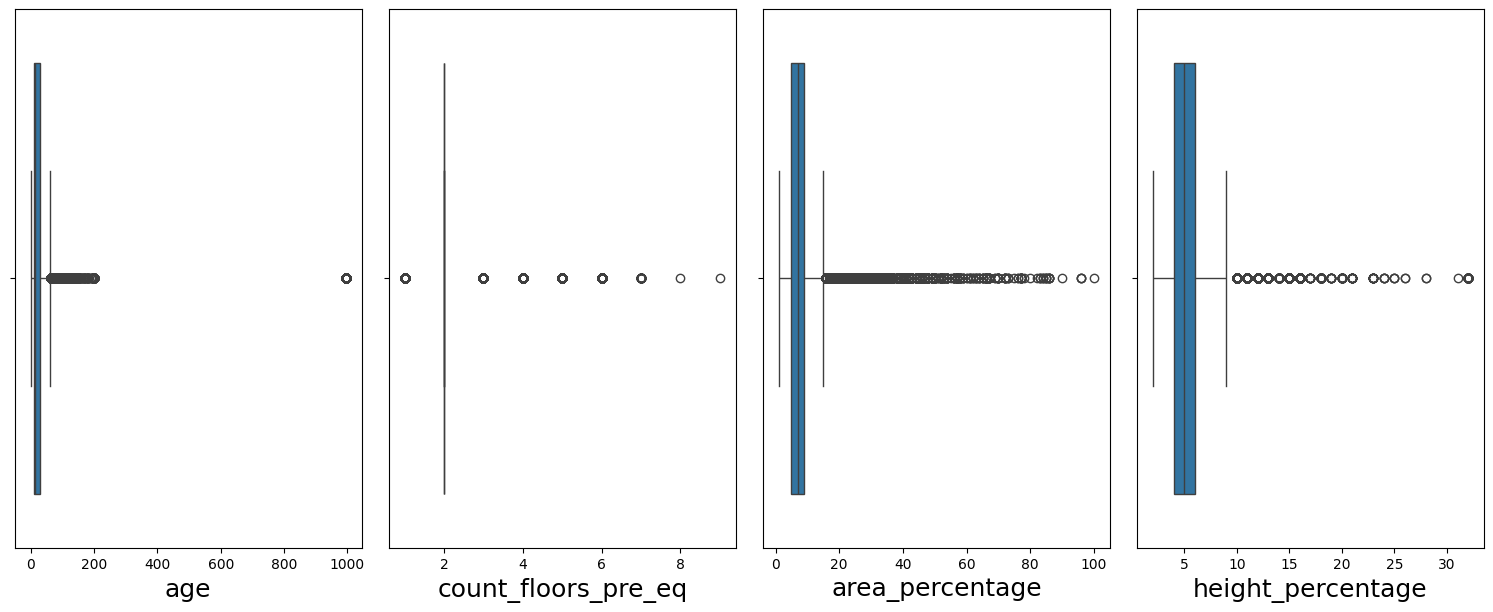

In [ ]:
plt.figure(figsize=(30,30))              # To fixed the canvas size
plotnumber = 1                           # Initialize the plotnumber
for i in df[['age','count_floors_pre_eq','area_percentage','height_percentage']]:                   # Using foor loop to visualize the each column
    plt.subplot(5,8,plotnumber)          # assign a plotnumber for each columns
    sns.boxplot(x=df[i])                 # using countplot to visualize how it affects the skin diseases
    plt.xlabel(i,fontsize=18)            # change the font size of x label
    plotnumber += 1                      # increament the plot number by one
plt.tight_layout()                       # using the tight layout to adjust space and don't overlap the  figure
plt.show()

In [ ]:
 for i in df[['age','count_floors_pre_eq','area_percentage','height_percentage']]:
  # Calculate quartiles
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  # Calculate IQR
  IQR = Q3 - Q1
  print(i,'IQR',IQR)
  # Define lower and upper bounds
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print(i,'LB',lower_bound)
  print(i,'UB',upper_bound)
# check outliers
  print(i,df[(df[i] < lower_bound) & (df[i] > upper_bound)].shape)
  print('='*40)


age IQR 20.0
age LB -20.0
age UB 60.0
age (0, 40)
count_floors_pre_eq IQR 0.0
count_floors_pre_eq LB 2.0
count_floors_pre_eq UB 2.0
count_floors_pre_eq (0, 40)
area_percentage IQR 4.0
area_percentage LB -1.0
area_percentage UB 15.0
area_percentage (0, 40)
height_percentage IQR 2.0
height_percentage LB 1.0
height_percentage UB 9.0
height_percentage (0, 40)


####**Insights**
* As we observed, the age, count_floors_pre_eq, area_percentage, and height_percentage columns show outliers under IQR range , so we can't use trimming or capping method on those because these records are real and important for ML modeling.These records show the various detailing of data.
* So, for handling the outliers, we'll use robust scaling and tree-based models.

### **Feature Scaling**

In [ ]:
# scaling the numerical columns
df.num_cols = df[df.select_dtypes(include='int64').drop(['building_id','damage_grade'],axis=1).columns]
df.num_cols

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,6,487,12198,2,30,6,5,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,8,900,2812,2,10,8,7,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,21,363,8973,2,10,5,5,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,22,418,10694,2,10,6,5,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,11,131,1488,3,30,8,9,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,25,1335,1621,1,55,6,3,0,1,0,...,0,0,0,0,0,0,0,0,0,0
260597,17,715,2060,2,0,6,5,0,1,0,...,0,0,0,0,0,0,0,0,0,0
260598,17,51,8163,3,55,6,7,0,1,0,...,0,0,0,0,0,0,0,0,0,0
260599,26,39,1851,2,10,14,6,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
sc_num_cols = scaler.fit_transform(df.num_cols)
sc_num_cols = pd.DataFrame(sc_num_cols,columns=['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other'])
sc_num_cols

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,-0.428571,-0.307143,0.935163,0.0,0.75,-0.25,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.285714,0.282857,-0.545512,0.0,-0.25,0.25,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.642857,-0.484286,0.426408,0.0,-0.25,-0.50,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.714286,-0.405714,0.697902,0.0,-0.25,-0.25,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.071429,-0.815714,-0.754378,1.0,0.75,0.25,2.0,1.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,0.928571,0.904286,-0.733396,-1.0,2.00,-0.25,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260597,0.357143,0.018571,-0.664143,0.0,-0.75,-0.25,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260598,0.357143,-0.930000,0.298628,1.0,2.00,-0.25,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260599,1.000000,-0.947143,-0.697113,0.0,-0.25,1.75,0.5,0.0,-1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

df.select_dtypes(include='int64').drop(['building_id','damage_grade'],axis=1).columns

Index(['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other'],
      dtype='object')

In [ ]:
# dropping before scaling numerical columns
new_data = df.drop(columns=['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'count_families', 'has_secondary_use', 'has_secondary_use_agriculture',
       'has_secondary_use_hotel', 'has_secondary_use_rental',
       'has_secondary_use_institution', 'has_secondary_use_school',
       'has_secondary_use_industry', 'has_secondary_use_health_post',
       'has_secondary_use_gov_office', 'has_secondary_use_use_police',
       'has_secondary_use_other'],axis=1)
new_data

,building_id,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,legal_ownership_status,damage_grade
0,802906,t,r,n,f,q,t,d,v,3
1,28830,o,r,n,x,q,s,d,v,2
2,94947,t,r,n,f,x,t,d,v,3
3,590882,t,r,n,f,x,s,d,v,2
4,201944,t,r,n,f,x,s,d,v,3
...,...,...,...,...,...,...,...,...,...,...
260596,688636,n,r,n,f,j,s,q,v,2
260597,669485,t,r,n,f,q,s,d,v,3
260598,602512,t,r,q,f,q,s,d,v,3
260599,151409,t,r,x,v,s,j,d,v,2


### **One Hot Encoding**

In [ ]:
# applying OHE encoding on all categorical data
en_data = pd.get_dummies(new_data.drop(['building_id','damage_grade'],axis=1),drop_first=True)
en_data

,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,ground_floor_type_m,ground_floor_type_v,...,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
260597,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
260598,False,True,False,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
260599,False,True,False,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# creating new Dataframe with scaling, encoding columns with target column and building_id
new_df = pd.concat([df[['building_id','damage_grade']],en_data,sc_num_cols],axis=1)
new_df

,building_id,damage_grade,land_surface_condition_o,land_surface_condition_t,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_q,roof_type_x,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,3,False,True,False,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,28830,2,True,False,False,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,94947,3,False,True,False,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,590882,2,False,True,False,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,201944,3,False,True,False,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,2,False,False,False,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260597,669485,3,False,True,False,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260598,602512,3,False,True,False,True,False,False,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
260599,151409,2,False,True,False,True,False,False,False,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


 ## **8. Feature Selection**

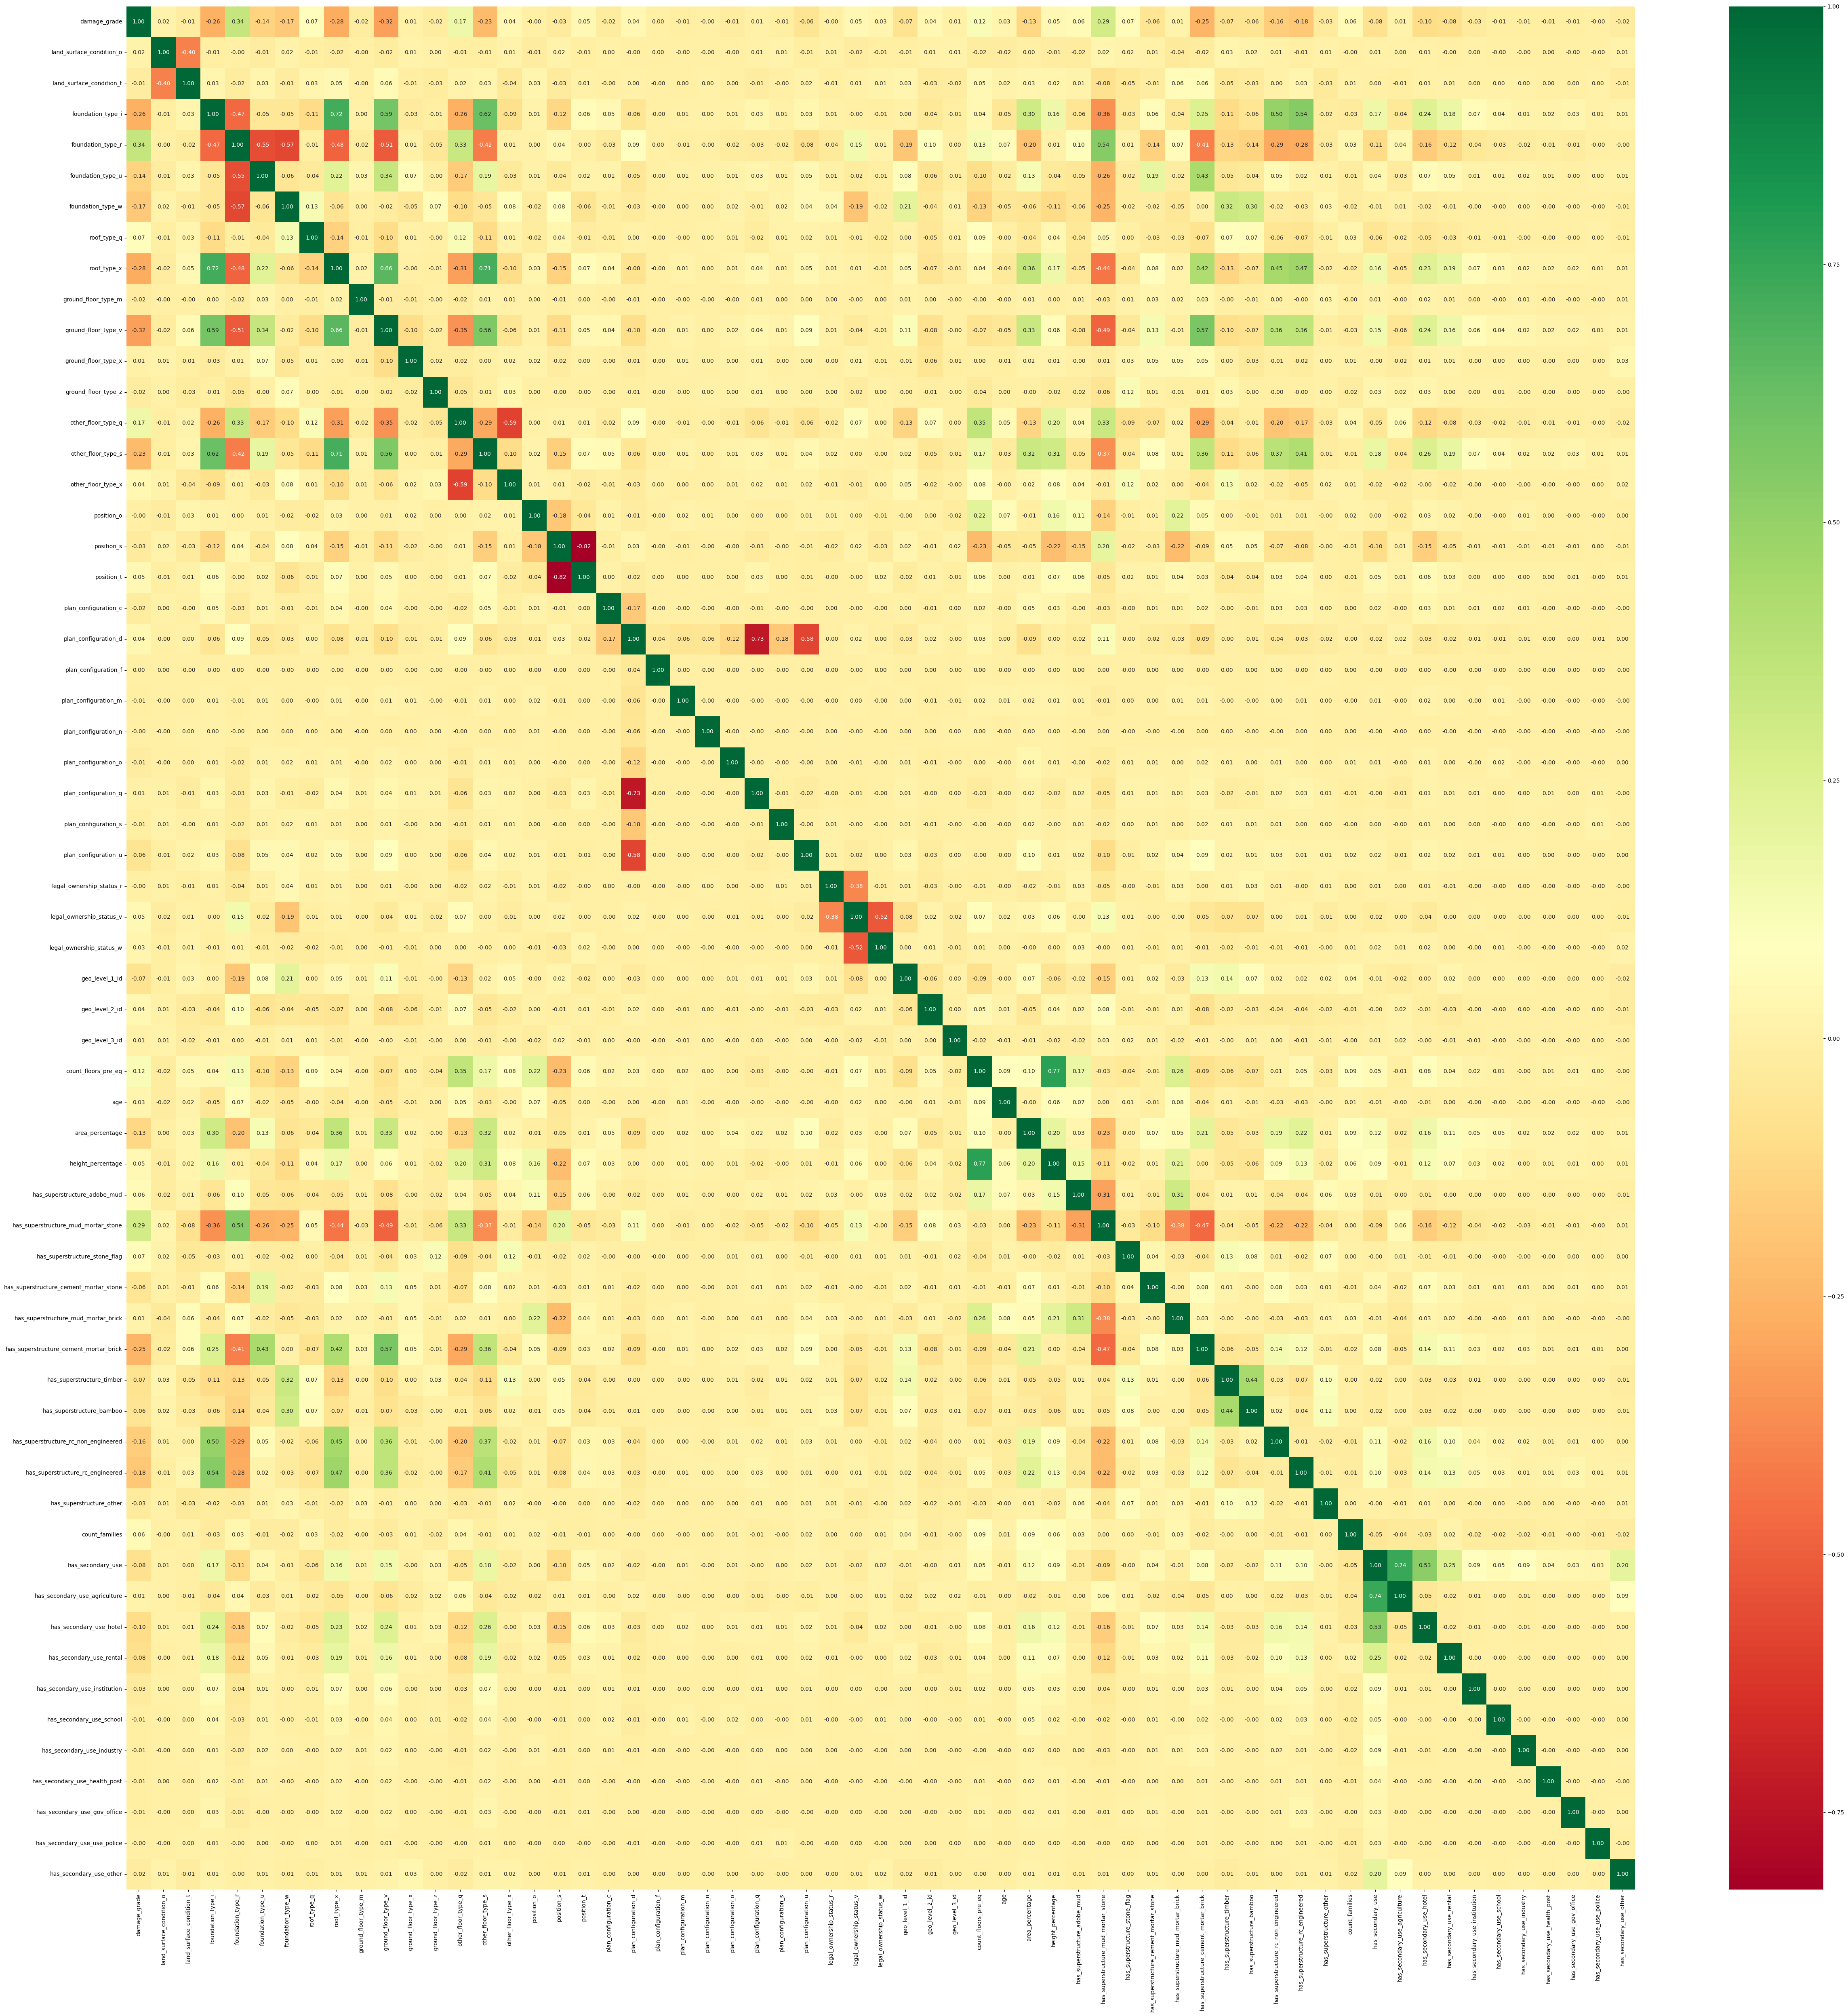

In [ ]:
# to check features correlation for feature selection
plt.figure(figsize=(50,50))
sns.heatmap(new_df.drop('building_id',axis=1).corr(),cmap='RdYlGn',annot=True,fmt='.2f')
plt.tight_layout()
plt.show()

#### **Insights**
* From this heatmap, we observed that there is no high multicollinearity between input features

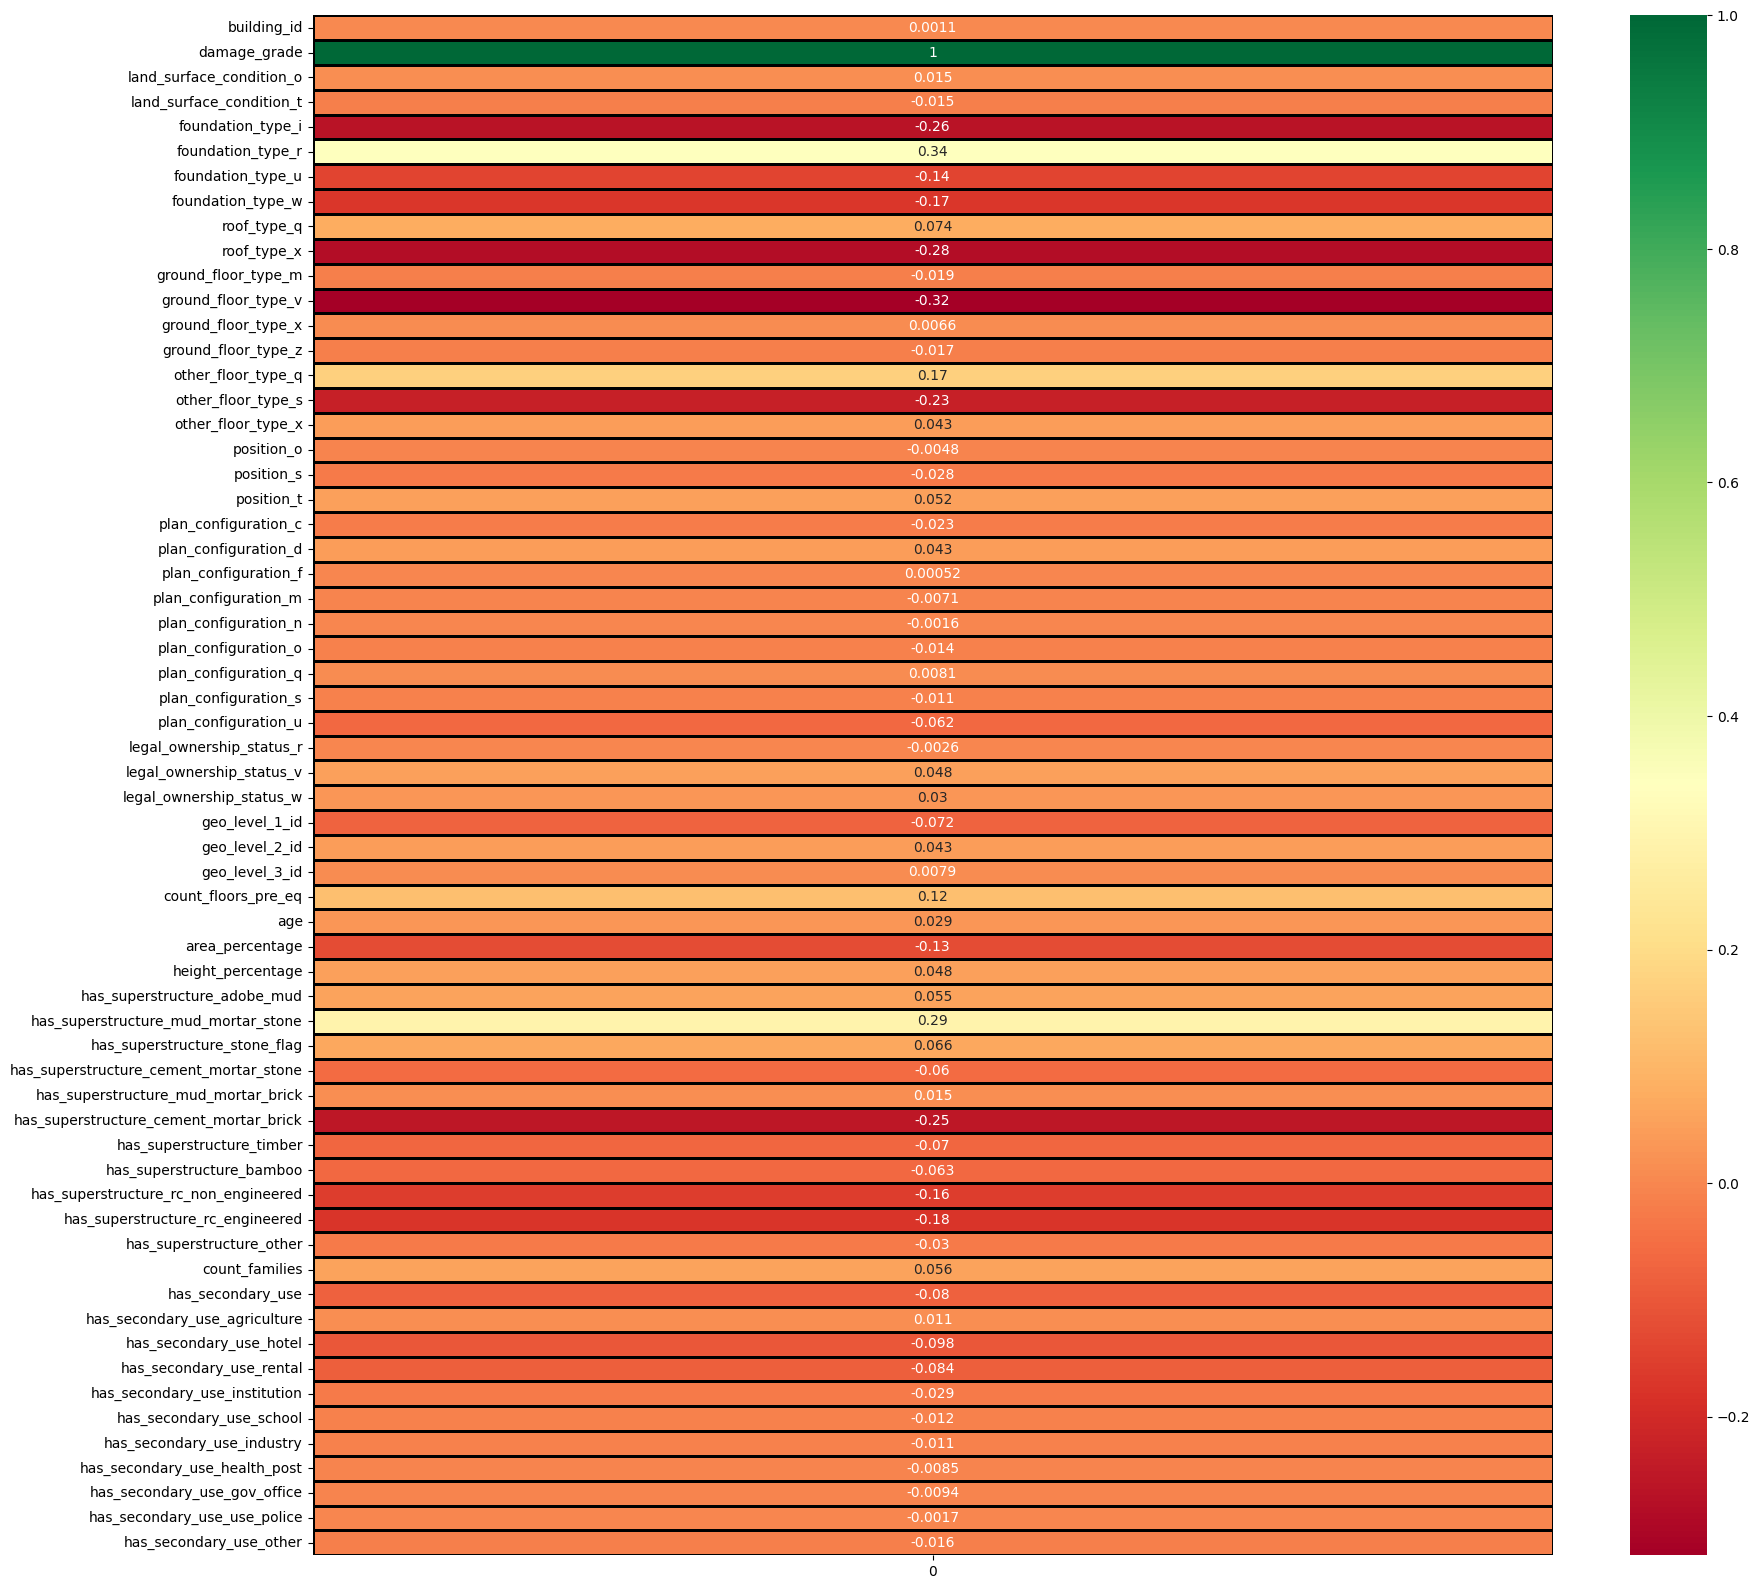

In [ ]:
# to check correlation with target column
plt.figure(figsize=(20,20))
correlations = new_df.corrwith(new_df["damage_grade"])
sns.heatmap(pd.DataFrame(correlations), annot=True,cmap='RdYlGn',linewidths=2,linecolor='black')
plt.show()

#### **Insights**
* There is no high correlation with target column.
* For training the model, we use all the input features.

## **9. Train Test Split**

In [ ]:
X = new_df.drop('damage_grade',axis = 1)

* Since we use XGBoost algorithm, it's prefer zero index target labels.
* Target labels change to:
  - Grade 1 --> 0
  - Grade 2 --> 1
  - Grade 3 --> 2

In [ ]:
y = df['damage_grade']
y = y-1
y.head(10)

,damage_grade
0,2
1,1
2,2
3,1
4,2
5,1
6,2
7,0
8,1
9,0


In [ ]:
# Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(208480, 61)

In [ ]:
X_test.shape

(52121, 61)

In [ ]:
y_train.shape

(208480,)

In [ ]:
y_test.shape

(52121,)

### **Data Balancing**

* The data of each target class is imbalanced. For handling this data, I use SMOTE for data balancing.
* We use SMOTE for linear models, not for trees and boosting models, to avoid overfitting and data memorisation.
* For tree and boosting models, we use the (class_weight = 'balanced') term as given parameters.

In [ ]:
# balancing the data
from collections import Counter
from imblearn.over_sampling import SMOTE
sm = SMOTE()
print('\nActual Classes\n',Counter(y_train))
print('====================================')
X_sm,y_sm = sm.fit_resample(X_train,y_train)
print('Smote Classes\n',Counter(y_sm))


Actual Classes
 Counter({1: 118772, 2: 69754, 0: 19954})
Smote Classes
 Counter({1: 118772, 2: 118772, 0: 118772})


In [ ]:
X_sm.shape

(356316, 61)

In [ ]:
y_sm.shape

(356316,)

## **10. Model Building**

In [ ]:
# importing all model and model evalution metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report
from sklearn.model_selection import RandomizedSearchCV





### **Logistic Regression**

In [ ]:
lr = LogisticRegression(random_state = 52)
lr.fit(X_sm,y_sm)

LogisticRegression(random_state=52)

In [ ]:
lr_train_pred= lr.predict(X_train)
lr_train_pred

array([2, 2, 2, ..., 1, 1, 1])

In [ ]:
lr_pred = lr.predict(X_test)
lr_pred

array([1, 2, 0, ..., 2, 2, 1])

In [ ]:
lr_train_acc = accuracy_score(y_train,lr_train_pred)
lr_train_acc

0.4689802379125096

In [ ]:
lr_acc = accuracy_score(y_test,lr_pred)
lr_acc

0.4739548358627041

In [ ]:
lr_train_f1 = f1_score(y_train,lr_train_pred,average = 'macro')
lr_train_f1

0.46525770674007144

In [ ]:
lr_f1 = f1_score(y_test,lr_pred,average = 'macro')
lr_f1

0.47216944772983993

In [ ]:
confusion_matrix(y_test,lr_pred)

array([[ 3400,  1048,   722],
       [ 5027, 10646, 13814],
       [ 1097,  5710, 10657]])

In [ ]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.36      0.66      0.46      5170
           1       0.61      0.36      0.45     29487
           2       0.42      0.61      0.50     17464

    accuracy                           0.47     52121
   macro avg       0.46      0.54      0.47     52121
weighted avg       0.52      0.47      0.47     52121



* This model has good fit with no overfitting and underfitting


### **Decision Tree Classifier**

In [ ]:
# used training data with class weight(balanced)
dt = DecisionTreeClassifier(random_state=52, class_weight= 'balanced')
dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=52)

In [ ]:
dt_train_pred= dt.predict(X_train)
dt_train_pred

array([1, 1, 2, ..., 1, 2, 1])

In [ ]:
dt_pred = dt.predict(X_test)
dt_pred

array([2, 0, 1, ..., 2, 1, 1])

In [ ]:
dt_train_acc = accuracy_score(y_train,dt_train_pred)
dt_train_acc

1.0

In [ ]:
dt_acc = accuracy_score(y_test,dt_pred)
dt_acc

0.6456514648606128

In [ ]:
dt_train_f1 = f1_score(y_train,dt_train_pred,average = 'macro')
dt_train_f1

1.0

In [ ]:
dt_f1 = f1_score(y_test,dt_pred,average = 'macro')
dt_f1

0.5925398227338756

In [ ]:
confusion_matrix(y_test,dt_pred)

array([[ 2423,  2376,   371],
       [ 2288, 20678,  6521],
       [  358,  6555, 10551]])

In [ ]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.48      0.47      0.47      5170
           1       0.70      0.70      0.70     29487
           2       0.60      0.60      0.60     17464

    accuracy                           0.65     52121
   macro avg       0.59      0.59      0.59     52121
weighted avg       0.65      0.65      0.65     52121



* This model has overfitting with default parameters.

##### **Hyperparameter Tuning**

In [ ]:
params = {"criterion":('gini','entropy'),
         "splitter":('best','random'),
         "max_depth":(list(range(900,1000))),
         "min_samples_split":[2,3,4,5],
         "min_samples_leaf":(list(range(200,250)))
 }

In [ ]:
# df1_model = DecisionTreeClassifier(random_state=52)
# df_cv = RandomizedSearchCV(df1_model,params,scoring= 'f1',n_jobs= -1, verbose= 2,cv= 5)
# df_cv.fit(X_train,y_train)

In [ ]:
# best_params= df_cv.best_params_
# print(f" Best_Parameters:,{best_params}")

In [ ]:
dt1 = DecisionTreeClassifier(splitter= 'random', min_samples_split= 4, min_samples_leaf= 204, max_depth= 992, criterion= 'gini', class_weight= 'balanced', random_state=52)
dt1.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=992,
                       min_samples_leaf=204, min_samples_split=4,
                       random_state=52, splitter='random')

In [ ]:
dt1_train_pred= dt1.predict(X_train)
dt1_train_pred

array([0, 1, 1, ..., 1, 2, 1])

In [ ]:
dt1_pred = dt1.predict(X_test)
dt1_pred

array([2, 1, 0, ..., 1, 2, 0])

In [ ]:
dt1_train_acc = accuracy_score(y_train,dt1_train_pred)
dt1_train_f1 = f1_score(y_train,dt1_train_pred,average='macro')
print('accuracy',dt1_train_acc)
print('f1',dt1_train_f1)

accuracy 0.5919320798158096
f1 0.5703795969395514


In [ ]:
dt1_acc = accuracy_score(y_test,dt1_pred)
dt1_f1 = f1_score(y_test,dt1_pred,average='macro')
print('accuracy',dt1_acc)
print('f1',dt1_f1)

accuracy 0.5912204293854685
f1 0.5717351379893647


In [ ]:
confusion_matrix(y_test,dt1_pred)

array([[ 4185,   815,   170],
       [ 6882, 14580,  8025],
       [ 1063,  4351, 12050]])

In [ ]:
print(classification_report(y_test,dt1_pred))

              precision    recall  f1-score   support

           0       0.35      0.81      0.48      5170
           1       0.74      0.49      0.59     29487
           2       0.60      0.69      0.64     17464

    accuracy                           0.59     52121
   macro avg       0.56      0.66      0.57     52121
weighted avg       0.65      0.59      0.60     52121



* After hyperparameter tuning, this model has good fit with no overfitting or underfitting

### **Random Forest Classfier**

In [ ]:
rf = RandomForestClassifier(random_state=52,  class_weight= 'balanced')
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=52)

In [ ]:
rf_train_pred = rf.predict(X_train)
rf_train_pred

array([1, 1, 2, ..., 1, 2, 1])

In [ ]:
rf_pred = rf.predict(X_test)
rf_pred

array([2, 1, 1, ..., 1, 2, 1])

In [ ]:
rf_train_acc = accuracy_score(y_train,rf_train_pred)
rf_train_f1 = f1_score(y_train,rf_train_pred,average='macro')
print('accuracy',rf_train_acc)
print('f1',rf_train_f1)

accuracy 0.9999952033768227
f1 0.9999902440036205


In [ ]:
rf_acc = accuracy_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred,average='macro')
print('accuracy',rf_acc)
print('f1',rf_f1)

accuracy 0.7133017401815007
f1 0.6468476553950561


In [ ]:
confusion_matrix(y_test,rf_pred)

array([[ 2234,  2855,    81],
       [  930, 25121,  3436],
       [   98,  7543,  9823]])

In [ ]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.68      0.43      0.53      5170
           1       0.71      0.85      0.77     29487
           2       0.74      0.56      0.64     17464

    accuracy                           0.71     52121
   macro avg       0.71      0.62      0.65     52121
weighted avg       0.71      0.71      0.70     52121



* This model has overfitting with default parameters.

##### **Hyperparameter Tuning**

In [ ]:
n_estimators = [300, 400, 500]
max_features = ['sqrt','log2']
max_depth = [None, 10, 15, 20, 25]
max_depth.append(None)
min_samples_split = [2, 10, 20, 50]
min_samples_leaf = [1, 5, 10, 20]
bootstrap = [True,False]
class_weight=['balanced']




In [ ]:
random_grid = {'n_estimators':n_estimators,
               'max_features':max_features,
               'max_depth':max_depth,
               'min_samples_split':min_samples_split,
               'min_samples_leaf':min_samples_leaf,
               'bootstrap':bootstrap,
               'class_weight': class_weight
}

In [ ]:
# rf_hy = RandomForestClassifier(random_state=52)
# rf_cv = RandomizedSearchCV(estimator= rf_hy,param_distributions= random_grid,scoring= 'f1_macro',n_jobs= -1, verbose= 2,cv= 2,n_iter= 10)
# rf_cv.fit(X_train,y_train)


In [ ]:
# rf_best_params= rf_cv.best_params_
# print(f" RF nBest_Parameters:,{rf_best_params}")

In [ ]:
rf2 = RandomForestClassifier(n_estimators= 500, min_samples_split= 2, min_samples_leaf= 2, max_features= 'log2', max_depth= 20, class_weight= 'balanced', bootstrap= False, random_state=52)
rf2.fit(X_train,y_train)

RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=20,
                       max_features='log2', min_samples_leaf=2,
                       n_estimators=500, random_state=52)

In [ ]:
rf2_train_pred = rf2.predict(X_train)
rf2_train_pred

array([1, 1, 2, ..., 1, 2, 1])

In [ ]:
rf2_pred = rf2.predict(X_test)
rf2_pred

array([2, 1, 1, ..., 1, 2, 1])

In [ ]:
rf2_train_acc = accuracy_score(y_train,rf2_train_pred)
rf2_train_f1 = f1_score(y_train,rf2_train_pred,average='macro')
print('accuracy',rf2_train_acc)
print('f1',rf2_train_f1)

accuracy 0.7080247505755948
f1 0.6934844322780767


In [ ]:
rf2_acc = accuracy_score(y_test,rf2_pred)
rf2_f1 = f1_score(y_test,rf2_pred,average='macro')
print('accuracy',rf2_acc)
print('f1',rf2_f1)

accuracy 0.6371136394159743
f1 0.6191078928625747


In [ ]:
confusion_matrix(y_test,rf2_pred)

array([[ 3633,  1199,   338],
       [ 3682, 16877,  8928],
       [  421,  4346, 12697]])

In [ ]:
print(classification_report(y_test,rf2_pred))

              precision    recall  f1-score   support

           0       0.47      0.70      0.56      5170
           1       0.75      0.57      0.65     29487
           2       0.58      0.73      0.64     17464

    accuracy                           0.64     52121
   macro avg       0.60      0.67      0.62     52121
weighted avg       0.67      0.64      0.64     52121



* After hyperparameter tuning, this model has a good fit with no  overfitting or underfitting

### **Gradient Boosting**

In [ ]:
gb = GradientBoostingClassifier(n_estimators=120,random_state=52)
gb.fit(X_train,y_train)

GradientBoostingClassifier(n_estimators=120, random_state=52)

In [ ]:
gb_train_pred = gb.predict(X_train)
gb_train_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
gb_pred = gb.predict(X_test)
gb_pred

array([1, 1, 1, ..., 1, 2, 1])

In [ ]:
gb_train_acc = accuracy_score(y_train,gb_train_pred)
gb_train_f1 = f1_score(y_train,gb_train_pred,average='macro')
print('accuracy',gb_train_acc)
print('f1',gb_train_f1)

accuracy 0.6849961627014581
f1 0.6022010744514711


In [ ]:
gb_acc = accuracy_score(y_test,gb_pred)
gb_f1 = f1_score(y_test,gb_pred,average='macro')
print('accuracy',gb_acc)
print('f1',gb_f1)

accuracy 0.6843690642927035
f1 0.6031868454182798


In [ ]:
confusion_matrix(y_test,gb_pred)

array([[ 1927,  3194,    49],
       [  923, 25381,  3183],
       [   48,  9054,  8362]])

In [ ]:
print(classification_report(y_test,gb_pred))

              precision    recall  f1-score   support

           0       0.66      0.37      0.48      5170
           1       0.67      0.86      0.76     29487
           2       0.72      0.48      0.58     17464

    accuracy                           0.68     52121
   macro avg       0.69      0.57      0.60     52121
weighted avg       0.69      0.68      0.67     52121



* This model has good fit with no overfitting or underfitting

### **XGBoost**

In [ ]:
xgb = XGBClassifier(random_state= 52,n_estimators= 120,class_weight='balanced')
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=120, n_jobs=None, ...)

In [ ]:
xgb_train_pred = xgb.predict(X_train)
xgb_train_pred

array([1, 1, 2, ..., 1, 1, 1])

In [ ]:
xgb_pred = xgb.predict(X_test)
xgb_pred

array([2, 1, 1, ..., 1, 2, 1])

In [ ]:
xgb_train_acc = accuracy_score(y_train,xgb_train_pred)
xgb_train_f1 = f1_score(y_train,xgb_train_pred,average='macro')
print('accuracy',xgb_train_acc)
print('f1',xgb_train_f1)

accuracy 0.7528683806600154
f1 0.7026613562116345


In [ ]:
xgb_acc = accuracy_score(y_test,xgb_pred)
xgb_f1 = f1_score(y_test,xgb_pred,average='macro')
print('accuracy',xgb_acc)
print('f1',xgb_f1)

accuracy 0.7266360967748124
f1 0.6663125192764453


In [ ]:
confusion_matrix(y_test,xgb_pred)

array([[ 2370,  2737,    63],
       [  879, 25155,  3453],
       [   88,  7028, 10348]])

In [ ]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.71      0.46      0.56      5170
           1       0.72      0.85      0.78     29487
           2       0.75      0.59      0.66     17464

    accuracy                           0.73     52121
   macro avg       0.73      0.63      0.67     52121
weighted avg       0.73      0.73      0.72     52121



* This model has good fit with no overfitting or underfitting

##### **Hyperparameter Tuning**

In [ ]:
param_grid = {
    'gamma':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4, 200],
    'learning_rate':[0.01,0.03,0.06,0.1,0.15,0.2,0.25,0.300000012,0.4,0.5,0.6,0.7],
    'max_depth': [5,6,7,8,9,10,11,12,13,14],
    'n_estimators': [50,65,80,100,115,130,150],
    'reg_alpha': [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
    'reg_lambda': [1,2,3,4,5,6,7,8,9,10]
}

In [ ]:
# xgb_hy = XGBClassifier(random_state= 52)
# xgb_cv = RandomizedSearchCV(estimator= xgb_hy, scoring= 'f1_macro', param_distributions= param_grid, n_iter= 15, cv= 2, verbose= 2,n_jobs= -1, random_state= 52)
# xgb_cv.fit(X_train,y_train)

In [ ]:
# xgb_best_params= xgb_cv.best_params_
# print(f" Best_Parameters:, {xgb_best_params}")

In [ ]:
xgb2 = XGBClassifier(reg_lambda= 6, reg_alpha= 1, n_estimators= 100, max_depth= 7, learning_rate= 0.300000012, gamma= 0.01, class_weight= 'balanced', random_state= 52,n_jobs= -1)
xgb2.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.01, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.300000012,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1, ...)

In [ ]:
xgb2_train_pred = xgb2.predict(X_train)
xgb2_train_pred

array([1, 1, 2, ..., 1, 1, 1])

In [ ]:
xgb2_pred = xgb2.predict(X_test)
xgb2_pred

array([2, 1, 1, ..., 1, 2, 1])

In [ ]:
xgb2_train_acc = accuracy_score(y_train,xgb2_train_pred)
xgb2_train_f1 = f1_score(y_train,xgb2_train_pred,average='macro')
print('accuracy',xgb2_train_acc)
print('f1',xgb2_train_f1)

accuracy 0.7611473522640061
f1 0.7124316634373944


In [ ]:
xgb2_acc = accuracy_score(y_test,xgb2_pred)
xgb2_f1 = f1_score(y_test,xgb2_pred,average='macro')
print('accuracy',xgb2_acc)
print('f1',xgb2_f1)

accuracy 0.7304733216937511
f1 0.6711181607030619


In [ ]:
confusion_matrix(y_test,xgb2_pred)

array([[ 2395,  2704,    71],
       [  877, 25194,  3416],
       [   72,  6908, 10484]])

In [ ]:
print(classification_report(y_test,xgb2_pred))

              precision    recall  f1-score   support

           0       0.72      0.46      0.56      5170
           1       0.72      0.85      0.78     29487
           2       0.75      0.60      0.67     17464

    accuracy                           0.73     52121
   macro avg       0.73      0.64      0.67     52121
weighted avg       0.73      0.73      0.72     52121



* After hyperparameter tuning, this model has good fit with no overfitting or underfitting

### **Deep Learning Model**

#### **Artificial Neural Network (ANN)**

In [ ]:
# import neural network library
from sklearn.neural_network import MLPClassifier
ann = MLPClassifier(hidden_layer_sizes= (80,3), learning_rate_init= 0.01, max_iter= 80,random_state = 52)
ann.fit(X_sm,y_sm)

MLPClassifier(hidden_layer_sizes=(80, 3), learning_rate_init=0.01, max_iter=80,
              random_state=52)

In [ ]:
ann_pred = ann.predict(X_test)
ann_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
ann_acc = accuracy_score(y_test,ann_pred)
ann_f1 = f1_score(y_test,ann_pred,average='macro')
print('accuracy',ann_acc)
print('f1',ann_f1)

accuracy 0.5657412559237159
f1 0.24088324674051564


In [ ]:
confusion_matrix(y_test,xgb2_pred)

array([[ 2395,  2704,    71],
       [  877, 25194,  3416],
       [   72,  6908, 10484]])

In [ ]:
print(classification_report(y_test,xgb2_pred))

              precision    recall  f1-score   support

           0       0.72      0.46      0.56      5170
           1       0.72      0.85      0.78     29487
           2       0.75      0.60      0.67     17464

    accuracy                           0.73     52121
   macro avg       0.73      0.64      0.67     52121
weighted avg       0.73      0.73      0.72     52121



## **7. Conclusion** ✅


### **🔍 Model Evaluation & Selection**

This project focused on predicting earthquake-induced building damage using structured survey data with significant **class imbalance**. Multiple models were evaluated, including **Logistic Regression**, **Decision Tree**, **Random Forest**, **Gradient Boosting**, **XGBoost**, and **ANN(MLP Classifier)**. Due to the non-linear relationships among features such as building age, construction material, floor count, and geographic indicators, tree-based ensemble models consistently outperformed linear models.

### **Model Comparison**

In [ ]:
# creating model comparison report using DataFrame
score = pd.DataFrame({"Models":["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier","GradientBoostingClassifier","XGBoostClassifier","ANN"],
                     "Accuracy before Tuning":[lr_acc*100,dt_acc*100,rf_acc*100,gb_acc*100,xgb_acc*100,ann_acc*100],
                      "Accuracy after Tuning":[ np.nan ,dt1_acc*100,rf2_acc*100,np.nan,xgb2_acc*100,np.nan],
                      "F1_score before Tuning":[lr_f1*100,dt_f1*100,rf_f1*100,gb_f1*100,xgb_f1*100,ann_f1*100],
                     "F1_score after Tuning":[np.nan,dt1_f1*100,rf2_f1*100,np.nan,xgb2_f1*100,np.nan]
                     })
score

,Models,Accuracy before Tuning,Accuracy after Tuning,F1_score before Tuning,F1_score after Tuning
0,LogisticRegression,47.395484,NaN,47.216945,NaN
1,DecisionTreeClassifier,64.565146,59.122043,59.253982,57.173514
2,RandomForestClassifier,71.330174,63.711364,64.684766,61.910789
3,GradientBoostingClassifier,68.436906,NaN,60.318685,NaN
4,XGBoostClassifier,72.663610,73.047332,66.631252,67.111816
5,ANN,56.574126,NaN,24.088325,NaN


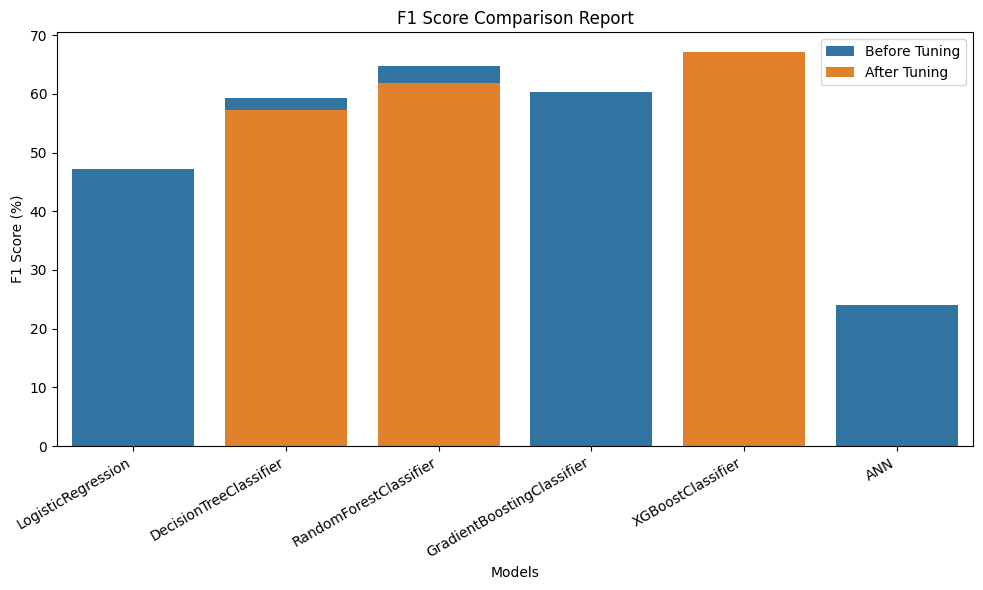

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=score['Models'],y=score['F1_score before Tuning'],label='Before Tuning')

sns.barplot(x=score['Models'],y=score['F1_score after Tuning'],label='After Tuning')

plt.xticks(rotation=30, ha='right')
plt.ylabel('F1 Score (%)')
plt.title('F1 Score Comparison Report')
plt.tight_layout()
plt.show()


### **⚙️ Final Model & Performance**

Among all models, **XGBoost** delivered the best performance with a **Macro F1-score** of **~0.67** on the test data, while maintaining a small **train–test gap (~0.04)**. Careful control of parameters such as reduced tree depth, lower learning rate, and increasing the penalty helped prevent overfitting and improved generalization. Macro F1 was chosen as the primary metric to ensure fair evaluation across all damage classes.

### **🚧 Challenges & Learnings**
Several challenges were encountered during this project:
* Class imbalance, which made accuracy misleading
* Overfitting in tree-based models, especially with default parameters
* Increased training time during hyperparameter tuning due to ensemble complexity
* Model sensitivity to synthetic data when SMOTE was applied with boosting models

Addressing these challenges required careful metric selection, controlled model complexity, and iterative experimentation.

## **Suggestions to Seismologists to Reduce Earthquake-Induced Building Damage**

- **Focus on building vulnerability, not just earthquake magnitude**
ML models show that damage severity is strongly influenced by building age, materials, floor count, and structural design—often more than seismic intensity alone.

- **Prioritize micro-zonation and geo-level risk mapping**
Geographic features consistently ranked among the most important predictors, indicating the need for localized seismic risk assessment instead of broad regional zoning.

- **Identify and retrofit high-risk building categories**
Structures with weak foundations, irregular layouts, and non-engineered materials were repeatedly associated with higher predicted damage grades.

- **Integrate ML-based damage prediction into early warning systems**
Predictive models can estimate expected damage in real time, allowing Alerts to be prioritised for structurally vulnerable zones.

- **Support data-driven updates to building codes**
Model insights highlight the effectiveness of reinforced materials and regular building geometry, supporting stricter construction standards in seismic regions.

- **Use post-earthquake data to improve risk models continuously**
High-quality damage surveys are critical for retraining models and improving future earthquake damage predictions.



#                                                                 ---**Modeling Completed**---



